In [1]:
# ============================================================
# PART 3 - NLP & SEQUENCE MODELING PROJECT
# ============================================================

!pip install tensorflow nltk -q

# ============================================================
# IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense
)

import nltk

from nltk.corpus import stopwords

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [2]:
# ============================================================
# DATASET UPLOAD
# ============================================================

from google.colab import files
import zipfile
import os

uploaded = files.upload()

zip_file = list(uploaded.keys())[0]

# ============================================================
# EXTRACT ZIP FILE
# ============================================================

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall("dataset")

print("Dataset Extracted Successfully")

# ============================================================
# LOAD CSV
# ============================================================

csv_path = "dataset/ai_project_synthetic_datasets/part_3_nlp_sequence_modeling/customer_support_text_classification.csv"

df = pd.read_csv(csv_path)

print("\nDATASET LOADED SUCCESSFULLY")

Saving ai_project_synthetic_datasets-20260507T104855Z-3-001.zip to ai_project_synthetic_datasets-20260507T104855Z-3-001 (1).zip
Dataset Extracted Successfully

DATASET LOADED SUCCESSFULLY



================ TASK 1: DATASET UNDERSTANDING ================

NUMBER OF RECORDS:

(1500, 6)

SAMPLE TEXT RECORDS:

                                    customer_message sentiment_label
0  I need information about the payment process. ...         neutral
1      I need information about the payment process.         neutral
2  The refund process was fast and convenient. I ...        positive
3  My refund is still pending and this experience...        negative
4   Please tell me how to update my account details.         neutral

TARGET LABELS:

['neutral' 'positive' 'negative']

AVERAGE TEXT LENGTH:

72.75666666666666

CLASS DISTRIBUTION:

sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64


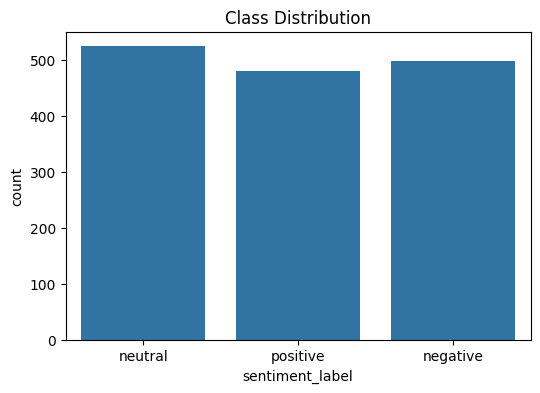

In [3]:
# ============================================================
# TASK 1: DATASET UNDERSTANDING
# ============================================================

print("\n================ TASK 1: DATASET UNDERSTANDING ================\n")

# ============================================================
# DATASET SHAPE
# ============================================================

print("NUMBER OF RECORDS:\n")

print(df.shape)

# ============================================================
# SAMPLE RECORDS
# ============================================================

print("\nSAMPLE TEXT RECORDS:\n")

print(df[['customer_message', 'sentiment_label']].head())

# ============================================================
# TARGET LABELS
# ============================================================

print("\nTARGET LABELS:\n")

print(df['sentiment_label'].unique())

# ============================================================
# AVERAGE TEXT LENGTH
# ============================================================

df['text_length'] = df['customer_message'].apply(len)

print("\nAVERAGE TEXT LENGTH:\n")

print(df['text_length'].mean())

# ============================================================
# CLASS DISTRIBUTION
# ============================================================

print("\nCLASS DISTRIBUTION:\n")

print(df['sentiment_label'].value_counts())

plt.figure(figsize=(6,4))

sns.countplot(
    x='sentiment_label',
    data=df
)

plt.title("Class Distribution")

plt.savefig("model_evaluation.png")

plt.show()

In [4]:
# ============================================================
# TASK 2: TEXT PREPROCESSING
# ============================================================

print("\n================ TASK 2: TEXT PREPROCESSING ================\n")

stop_words = set(stopwords.words('english'))

# ============================================================
# CLEANING FUNCTION
# ============================================================

def clean_text(text):

    # Lowercase
    text = text.lower()

    # Remove special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenization
    words = text.split()

    # Remove stopwords
    words = [
        word for word in words
        if word not in stop_words
    ]

    return " ".join(words)

# ============================================================
# APPLY CLEANING
# ============================================================

df['cleaned_text'] = df['customer_message'].apply(clean_text)

print("ORIGINAL TEXT:\n")

print(df['customer_message'][0])

print("\nCLEANED TEXT:\n")

print(df['cleaned_text'][0])

print("""
Preprocessing Steps Applied:
1. Lowercasing
2. Removing special characters
3. Tokenization
4. Stopword removal
""")


================ TASK 2: TEXT PREPROCESSING ================

ORIGINAL TEXT:

I need information about the payment process. My ticket number is 78732. Please respond as soon as possible.

CLEANED TEXT:

need information payment process ticket number please respond soon possible

Preprocessing Steps Applied:
1. Lowercasing
2. Removing special characters
3. Tokenization
4. Stopword removal



In [5]:
# ============================================================
# TASK 3: TEXT VECTORIZATION
# ============================================================

print("\n================ TASK 3: TEXT VECTORIZATION ================\n")

# ============================================================
# TF-IDF VECTORIZATION
# ============================================================

tfidf = TfidfVectorizer(
    max_features=5000
)

X = tfidf.fit_transform(df['cleaned_text'])

y = df['sentiment_label']

print("TF-IDF FEATURE MATRIX SHAPE:\n")

print(X.shape)

print("""
Why text must be converted into vectors?

Machine learning models cannot understand raw text directly.
Text vectorization converts words into numerical representations
so models can process and learn patterns from text data.
""")


================ TASK 3: TEXT VECTORIZATION ================

TF-IDF FEATURE MATRIX SHAPE:

(1500, 146)

Why text must be converted into vectors?

Machine learning models cannot understand raw text directly.
Text vectorization converts words into numerical representations
so models can process and learn patterns from text data.




================ TASK 4: BASELINE MODEL ================

MODEL ACCURACY:

1.0

CLASSIFICATION REPORT:

              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       109
     neutral       1.00      1.00      1.00       104
    positive       1.00      1.00      1.00        87

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



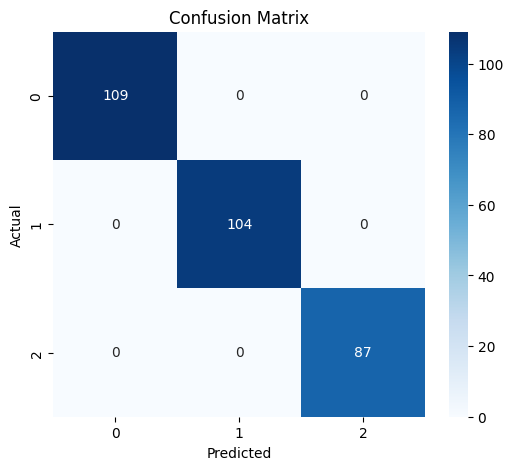

In [6]:
# ============================================================
# TASK 4: BASELINE MODEL
# ============================================================

print("\n================ TASK 4: BASELINE MODEL ================\n")

# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ============================================================
# LOGISTIC REGRESSION MODEL
# ============================================================

model = LogisticRegression()

model.fit(X_train, y_train)

# ============================================================
# PREDICTIONS
# ============================================================

y_pred = model.predict(X_test)

# ============================================================
# EVALUATION
# ============================================================

accuracy = accuracy_score(y_test, y_pred)

print("MODEL ACCURACY:\n")

print(accuracy)

print("\nCLASSIFICATION REPORT:\n")

print(classification_report(y_test, y_pred))

# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [7]:
# ============================================================
# TASK 5: SEQUENCE MODEL (LSTM)
# ============================================================

print("\n================ TASK 5: SEQUENCE MODEL ================\n")

# ============================================================
# TOKENIZER
# ============================================================

tokenizer = Tokenizer(num_words=5000)

tokenizer.fit_on_texts(df['cleaned_text'])

sequences = tokenizer.texts_to_sequences(df['cleaned_text'])

# ============================================================
# PADDING
# ============================================================

max_length = 50

X_seq = pad_sequences(
    sequences,
    maxlen=max_length,
    padding='post'
)

# ============================================================
# LABEL ENCODING
# ============================================================

label_mapping = {
    'negative':0,
    'neutral':1,
    'positive':2
}

y_seq = df['sentiment_label'].map(label_mapping)

# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_seq,
    y_seq,
    test_size=0.2,
    random_state=42
)

# ============================================================
# BUILD LSTM MODEL
# ============================================================

lstm_model = Sequential()

# Embedding Layer
lstm_model.add(
    Embedding(
        input_dim=5000,
        output_dim=64,
        input_length=max_length
    )
)

# LSTM Layer
lstm_model.add(
    LSTM(64)
)

# Output Layer
lstm_model.add(
    Dense(
        3,
        activation='softmax'
    )
)

# ============================================================
# COMPILE MODEL
# ============================================================

lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print(lstm_model.summary())

print("""
Sequence Model Architecture:

1. Input Sequence
2. Embedding Layer
3. LSTM Layer
4. Output Layer

Loss Function:
Sparse Categorical Crossentropy

Evaluation Metric:
Accuracy
""")


================ TASK 5: SEQUENCE MODEL ================



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None

Sequence Model Architecture:

1. Input Sequence
2. Embedding Layer
3. LSTM Layer
4. Output Layer

Loss Function:
Sparse Categorical Crossentropy

Evaluation Metric:
Accuracy



In [8]:
# ============================================================
# TASK 5: LSTM TRAINING
# ============================================================

print("\n================ LSTM MODEL TRAINING ================\n")

history = lstm_model.fit(
    X_train_seq,
    y_train_seq,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)


================ LSTM MODEL TRAINING ================

Epoch 1/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - accuracy: 0.3406 - loss: 1.1008 - val_accuracy: 0.3292 - val_loss: 1.0991
Epoch 2/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.3552 - loss: 1.0985 - val_accuracy: 0.3292 - val_loss: 1.1006
Epoch 3/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.3552 - loss: 1.0988 - val_accuracy: 0.3292 - val_loss: 1.1013
Epoch 4/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.3552 - loss: 1.0983 - val_accuracy: 0.3292 - val_loss: 1.0996
Epoch 5/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.3552 - loss: 1.0981 - val_accuracy: 0.3292 - val_loss: 1.1000


In [9]:
# ============================================================
# TASK 5: SAMPLE PREDICTIONS
# ============================================================

print("\n================ SAMPLE PREDICTIONS ================\n")

predictions = lstm_model.predict(X_test_seq[:5])

predicted_labels = np.argmax(predictions, axis=1)

reverse_mapping = {
    0:'negative',
    1:'neutral',
    2:'positive'
}

output_lines = []

for i in range(5):

    text = df['cleaned_text'].iloc[i]

    prediction = reverse_mapping[predicted_labels[i]]

    result = f"TEXT: {text}\nPREDICTION: {prediction}\n"

    print(result)

    output_lines.append(result)

# ============================================================
# SAVE OUTPUTS
# ============================================================

with open("sample_predictions.txt", "w") as f:

    for line in output_lines:
        f.write(line + "\n")


================ SAMPLE PREDICTIONS ================

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
TEXT: need information payment process ticket number please respond soon possible
PREDICTION: neutral

TEXT: need information payment process
PREDICTION: neutral

TEXT: refund process fast convenient appreciate quick response
PREDICTION: neutral

TEXT: refund still pending experience frustrating ticket number
PREDICTION: neutral

TEXT: please tell update account details
PREDICTION: neutral



In [10]:
# ============================================================
# TASK 5: SAMPLE PREDICTIONS
# ============================================================

print("\n================ SAMPLE PREDICTIONS ================\n")

predictions = lstm_model.predict(X_test_seq[:5])

predicted_labels = np.argmax(predictions, axis=1)

reverse_mapping = {
    0:'negative',
    1:'neutral',
    2:'positive'
}

output_lines = []

for i in range(5):

    text = df['cleaned_text'].iloc[i]

    prediction = reverse_mapping[predicted_labels[i]]

    result = f"TEXT: {text}\nPREDICTION: {prediction}\n"

    print(result)

    output_lines.append(result)

# ============================================================
# SAVE OUTPUTS
# ============================================================

with open("sample_predictions.txt", "w") as f:

    for line in output_lines:
        f.write(line + "\n")


================ SAMPLE PREDICTIONS ================

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
TEXT: need information payment process ticket number please respond soon possible
PREDICTION: neutral

TEXT: need information payment process
PREDICTION: neutral

TEXT: refund process fast convenient appreciate quick response
PREDICTION: neutral

TEXT: refund still pending experience frustrating ticket number
PREDICTION: neutral

TEXT: please tell update account details
PREDICTION: neutral



In [11]:
# ============================================================
# TASK 6: ATTENTION & TRANSFORMER REFLECTION
# ============================================================

print("\n================ TASK 6: REFLECTION ================\n")

print("""
1. Why do RNNs struggle with long-term dependencies?

RNNs process text sequentially and may forget earlier information
when sequences become very long.

------------------------------------------------------------

2. How do LSTMs help with memory?

LSTMs use memory cells and gates to remember important
information for longer durations.

------------------------------------------------------------

3. What does Attention solve?

Attention allows models to focus on the most important words
in a sequence instead of treating all words equally.

------------------------------------------------------------

4. Why are Transformers important?

Transformers process sequences in parallel and use attention
mechanisms effectively, making them powerful for modern NLP
and Generative AI applications like ChatGPT.
""")


================ TASK 6: REFLECTION ================


1. Why do RNNs struggle with long-term dependencies?

RNNs process text sequentially and may forget earlier information
when sequences become very long.

------------------------------------------------------------

2. How do LSTMs help with memory?

LSTMs use memory cells and gates to remember important
information for longer durations.

------------------------------------------------------------

3. What does Attention solve?

Attention allows models to focus on the most important words
in a sequence instead of treating all words equally.

------------------------------------------------------------

4. Why are Transformers important?

Transformers process sequences in parallel and use attention
mechanisms effectively, making them powerful for modern NLP
and Generative AI applications like ChatGPT.



In [12]:
# ============================================================
# DOWNLOAD RESULT FILES
# ============================================================

from google.colab import files

files.download("model_evaluation.png")

files.download("sample_predictions.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>